## Inport required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the dataset

In [2]:
def load_csv():
    df = pd.read_csv("project_dataset.csv", sep=";", encoding="utf-8")
    return df

df = load_csv()

# Clean the dataset

## Define columns lists

In [3]:
required_columns = [
    "Date",
    "Gare de départ",
    "Gare d'arrivée",
    "Nombre de circulations prévues"
]

digital_columns = [
    "Durée moyenne du trajet",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min"
]

deleted_columns = [
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
]

numerics_fill_zero = [
    "Durée moyenne du trajet",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Nombre de trains en retard à l'arrivée"
]

average_delays = [
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)"
]

columns_delays = average_delays

plausible_limits = {
    "Retard moyen des trains en retard au départ": (-30, 180),
    "Retard moyen de tous les trains au départ": (-30, 120),
    "Retard moyen des trains en retard à l'arrivée": (-30, 180),
    "Retard moyen de tous les trains à l'arrivée": (-30, 120),
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": (-30, 180)
}

colomns_zero = [
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min"
]

print("Nombre de lignes initial :", len(df))

Nombre de lignes initial : 12070


## Delete the useless columns and replace missing values

In [4]:
df = df.drop(columns=[col for col in deleted_columns if col in df.columns])

df = df.drop_duplicates()
print("Après suppression doublons :", len(df))

for col in df.select_dtypes(include="object"):
    df[col] = df[col].astype(str).str.replace(r"[\r\n]+", " ", regex=True).str.strip()

df.replace("", np.nan, inplace=True)

for col in digital_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)\
                        .str.replace(r"[\s]", "", regex=True)\
                        .str.replace("%", "", regex=False)\
                        .str.replace(",", ".", regex=False)\
                        .str.replace("min", "", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=required_columns)
print("Après suppression valeurs manquantes :", len(df))

Après suppression doublons : 11896
Après suppression valeurs manquantes : 11659


## Replace important missing values by 0 or median

In [5]:
for col in numerics_fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in average_delays:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

## Formate date

In [6]:
df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m', errors='coerce')
df = df.dropna(subset=["Date"])
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df = df.drop("Date", axis=1)

## Clean delays columns

In [7]:
for col in columns_delays:
    if col in df.columns:
        min_val, max_val = plausible_limits[col]
        df = df[(df[col] >= min_val) & (df[col] <= max_val)]

for col in colomns_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0).clip(lower=0)

## Export cleaned dataset

In [8]:
fichier_sortie = "cleaned_dataset.csv"

df.to_csv(fichier_sortie, sep=";", index=False, encoding="utf-8")
print("Fichier nettoyé sauvegardé :", fichier_sortie)

Fichier nettoyé sauvegardé : cleaned_dataset.csv


# Data Visualization & Analysis

## Bar chart of the top 10 stations with most the delays

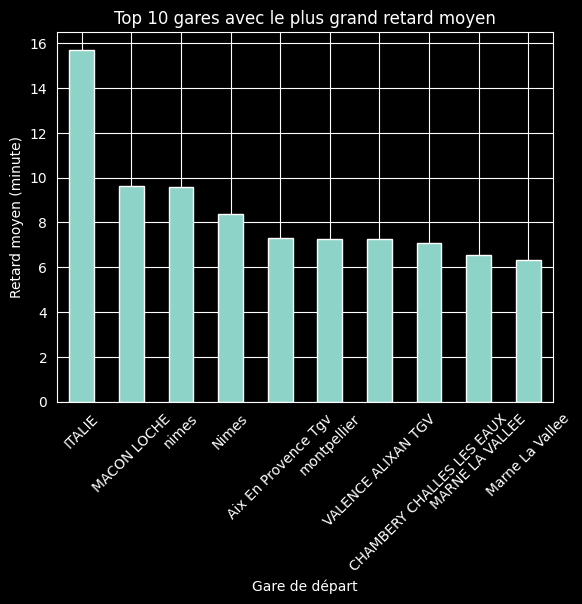

In [9]:
delay_by_station = (
    df.groupby("Gare de départ")["Retard moyen de tous les trains au départ"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
delay_by_station.plot(kind="bar")
plt.title("Top 10 gares avec le plus grand retard moyen")
plt.xlabel("Gare de départ")
plt.ylabel("Retard moyen (minute)")
plt.xticks(rotation=45)
plt.show()

## Pie chart of different times of delays

3070099.0 3070099.0


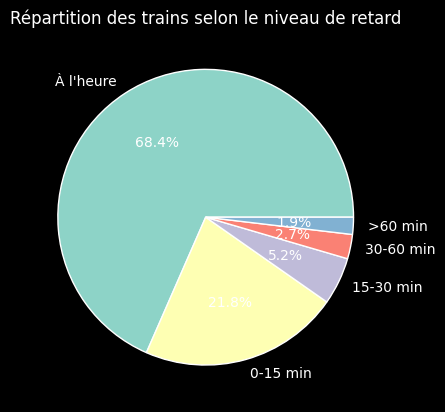

In [10]:
total_trains = df["Nombre de circulations prévues"].sum()
retard_15 = df["Nombre trains en retard > 15min"].sum()
retard_30 = df["Nombre trains en retard > 30min"].sum()
retard_60 = df["Nombre trains en retard > 60min"].sum()

more_than_60 = retard_60
between_30_60 = retard_30 - retard_60
between_15_30 = retard_15 - retard_30

total_retards = df["Nombre de trains en retard au départ"].sum()

between_0_15 = total_retards - retard_15
on_time = total_trains - total_retards

plt.figure()

labels = ["À l'heure", "0-15 min", "15-30 min", "30-60 min", ">60 min"]

sizes = [
    on_time,
    between_0_15,
    between_15_30,
    between_30_60,
    more_than_60
]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Répartition des trains selon le niveau de retard")
print(sum(sizes), total_trains)
plt.show()

## Dot chart of stations with the most canceled trains

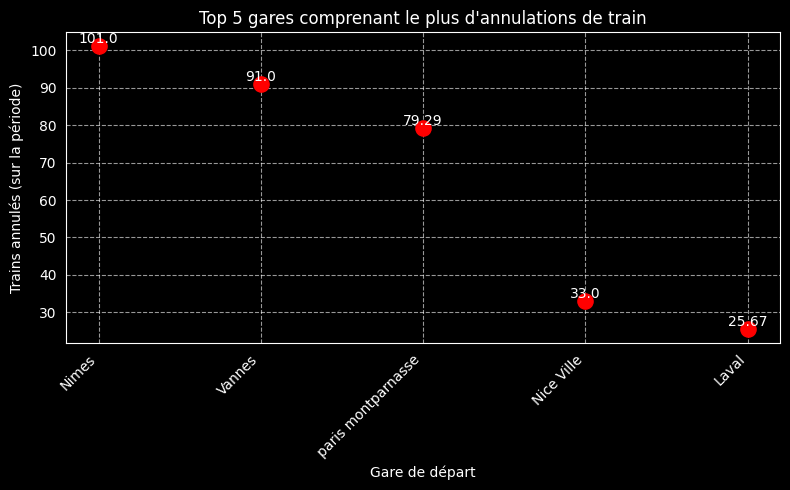

In [11]:
import matplotlib.pyplot as plt

delay_by_station = (
    df.groupby("Gare de départ")["Nombre de trains annulés"]
    .mean()
    .nlargest(5)  
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.scatter(delay_by_station.index, 
            delay_by_station.values, 
            color="red", 
            s=120)

for i, value in enumerate(delay_by_station.values):
    plt.text(i, value, round(value,2), 
             ha='center', va='bottom')

plt.title("Top 5 gares comprenant le plus d'annulations de train")
plt.xlabel("Gare de départ")
plt.ylabel("Trains annulés (sur la période)")

plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Bar chart comparing train delays at departure and arrival times for each year

<Figure size 640x480 with 0 Axes>

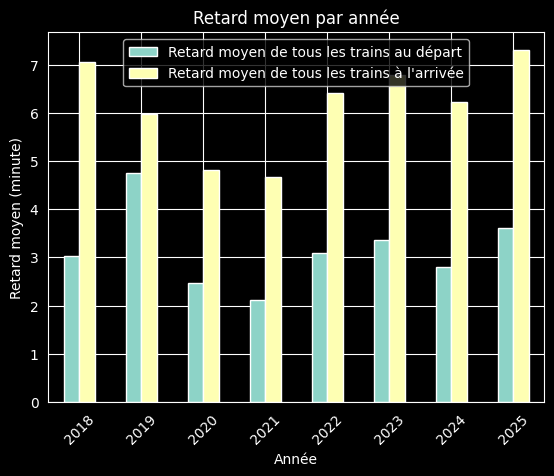

In [12]:
delay_by_station = (
    df.groupby("Year")[["Retard moyen de tous les trains au départ","Retard moyen de tous les trains à l'arrivée"]]
    .mean()
)

plt.figure()
delay_by_station.plot(kind="bar")
plt.title("Retard moyen par année")
plt.xlabel("Année")
plt.ylabel("Retard moyen (minute)")
plt.xticks(rotation=45)
plt.show()
